In [1]:
import os
import cv2
import matplotlib.pyplot as plt
import av
from fractions import Fraction
import pandas as pd

In [2]:

frames = []
for frame in range(0, 601):
    path = os.path.join("/home/levin/dev/Simulator/data/tmp/", f"frame_{frame:06d}.png")

    img = cv2.imread(path)
    frames.append(img)

In [3]:
df = pd.read_csv("/home/levin/dev/Simulator/data/outputs/coords.txt")

In [4]:
frames_roi = []
roi_size = 100
half_size = roi_size // 2

for idx, row in df.iterrows():
    x = int(row['screen_x'])
    y = int(row['screen_y'])
    x1 = max(x - half_size, 0)
    y1 = max(y - half_size, 0)
    x2 = min(x + half_size, frames[idx].shape[1])
    y2 = min(y + half_size, frames[idx].shape[0])
    roi = frames[idx][y1:y2, x1:x2].copy()
    frames_roi.append(roi)

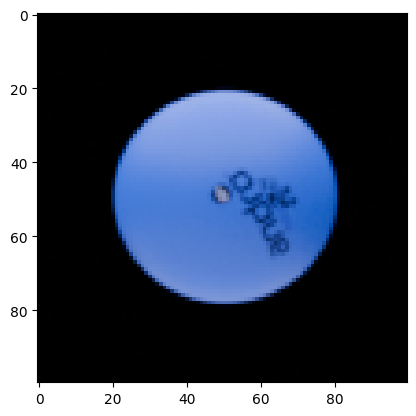

In [5]:
plt.imshow(frames_roi[500])

In [6]:
import sys
sys.path.append("../../src/utils/")
sys.path.append("../../src/utils/IEBCS/")
import eventIO
import numpy as np

In [19]:
buf = eventIO.load_hdf5("/home/levin/dev/Simulator/data/outputs/events.hdf5")
x = buf.x
y = buf.y
t = buf.ts
p = buf.p

In [8]:
print(f"Min timestamp: {t.min()}, Max timestamp: {t.max()}")
# Find the 150000 microsecond window with the most events
window_size_us = 150000
max_events = 0
best_start = 0

for start_us in range(int(t.min()), int(t.max()) - window_size_us + 1, 10000):
    end_us = start_us + window_size_us
    events_in_window = np.sum((t >= start_us) & (t < end_us))
    if events_in_window > max_events:
        max_events = events_in_window
        best_start = start_us

best_end = best_start + window_size_us
print(f"Best 150000 µs window: {best_start} - {best_end} µs")
print(f"Events in window: {max_events}")

Min timestamp: 0, Max timestamp: 159783
Best 150000 µs window: 0 - 150000 µs
Events in window: 2082012


In [86]:
# First comparison: first 9838 vs last 9838 microseconds
first_9838_mask = t < 9838
last_9838_mask = t > (t.max() - 9838)

events_first_9838 = np.sum(first_9838_mask)
events_last_9838 = np.sum(last_9838_mask)

print(f"Events in first 9838 µs: {events_first_9838}")
print(f"Events in last 9838 µs: {events_last_9838}")
print(f"Ratio (last/first): {events_last_9838 / events_first_9838:.2f}")
print()

# Second comparison: first 5000 vs last 5000 microseconds
first_5000_mask = t < 5000
last_5000_mask = t > (t.max() - 5000)

events_first_5000 = np.sum(first_5000_mask)
events_last_5000 = np.sum(last_5000_mask)

print(f"Events in first 5000 µs: {events_first_5000}")
print(f"Events in last 5000 µs: {events_last_5000}")
print(f"Ratio (last/first): {events_last_5000 / events_first_5000:.2f}")

Events in first 9838 µs: 108420
Events in last 9838 µs: 14611
Ratio (last/first): 0.13

Events in first 5000 µs: 39533
Events in last 5000 µs: 181
Ratio (last/first): 0.00


In [9]:
# Fixed binning: 601 bins, each 250 us, starting at t=0
bin_width_us = 250
n_bins = 601

t_start = 0  # start at t=0
t_end = t_start + n_bins * bin_width_us  # end after 601 bins

# exact integer edges (no float rounding)
bin_edges = t_start + np.arange(n_bins + 1, dtype=np.int64) * bin_width_us

# bin index per event
event_bins = np.searchsorted(bin_edges, t, side='right') - 1

# mark events outside the 601-frame window
event_bins[(t < bin_edges[0]) | (t > bin_edges[-1])] = -1


In [10]:
bin_idx = 0  # Replace with desired bin index
mask = event_bins == bin_idx
bin_events_x = x[mask]
bin_events_y = y[mask]
bin_events_t = t[mask]
bin_events_p = p[mask]

In [11]:
events_images = []
for bin_idx in range(n_bins):
    mask = event_bins == bin_idx
    bin_events_x = x[mask]
    bin_events_y = y[mask]
    bin_events_p = p[mask]
    event_img = np.zeros((720, 1280), dtype=np.float32)
    for ex, ey, ep in zip(bin_events_x, bin_events_y, bin_events_p):
        if ep == 1:
            event_img[ey, ex] += 1
        else:
            event_img[ey, ex] -= 1
    events_images.append(event_img)


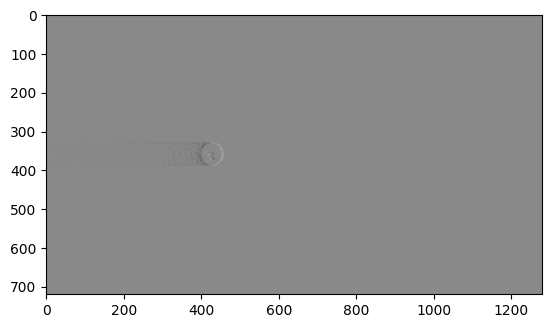

In [12]:
plt.imshow(events_images[200], cmap='gray')

In [13]:
# Normalize and convert events_images to uint8
events_images_uint8 = []
for event_img in events_images:
    # Normalize to 0-255 range
    img_min = event_img.min()
    img_max = event_img.max()
    
    if img_max - img_min > 0:
        normalized = ((event_img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        normalized = np.zeros_like(event_img, dtype=np.uint8)
    
    events_images_uint8.append(normalized)

In [23]:
events_roi = []
roi_size = 100
half_size = roi_size // 2

for idx, row in df.iterrows():
    x = int(row['screen_x'])
    y = int(row['screen_y'])
    x1 = max(x - half_size, 0)
    y1 = max(y - half_size, 0)
    x2 = min(x + half_size, events_images[idx].shape[1])
    y2 = min(y + half_size, events_images[idx].shape[0])
    roi = events_images[idx][y1:y2, x1:x2].copy()
    events_roi.append(roi)

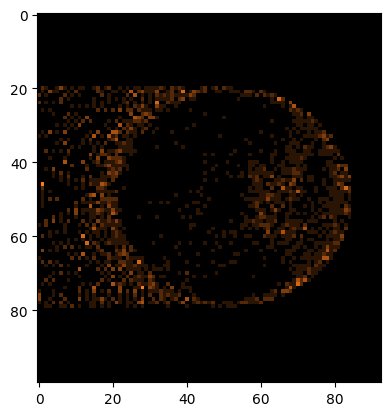

In [24]:
plt.imshow(events_roi[580])

In [16]:
# Convert events_roi to uint8 images (0-255 normalization)
events_roi_uint8 = []
for event_img in events_roi:
    img_min = event_img.min()
    img_max = event_img.max()
    if img_max - img_min > 0:
        normalized = ((event_img - img_min) / (img_max - img_min) * 255).astype(np.uint8)
    else:
        normalized = np.zeros_like(event_img, dtype=np.uint8)
    events_roi_uint8.append(normalized)

In [30]:
for i,j in zip(frames_roi, frames):
    i = cv2.cvtColor(i, cv2.COLOR_BGR2RGB)
    j = cv2.cvtColor(j, cv2.COLOR_BGR2RGB)

def write_video(frames_list, out_path, width, height, fps=30):
    container = av.open(out_path, mode='w')
    stream = container.add_stream('libx264', rate=fps)
    stream.width = width
    stream.height = height
    stream.pix_fmt = 'yuv420p'
    stream.options = {'crf': '18', "preset": "veryfast"}
    time_base = Fraction(1, fps)
    for i, img in enumerate(frames_list):
        # Ensure 3 channels and uint8
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 1:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
        elif img.shape[2] == 3:
            img = img
        else:
            raise ValueError("Unexpected image shape")
        frame = av.VideoFrame.from_ndarray(img, format='rgb24')
        frame.pts = i
        frame.time_base = time_base
        for packet in stream.encode(frame):
            container.mux(packet)
    for packet in stream.encode():
        container.mux(packet)
    container.close()

write_video(events_roi_uint8, '/home/levin/dev/Master_Thesis/data/events_roi.mp4', roi_size, roi_size)
write_video(frames_roi, '/home/levin/dev/Master_Thesis/data/frames_roi.mp4', roi_size, roi_size)
write_video(events_images_uint8, '/home/levin/dev/Master_Thesis/data/events_images.mp4', 1280, 720)
write_video(frames, '/home/levin/dev/Master_Thesis/data/frames.mp4', 1280, 720)

In [20]:
# new representation
H, W = 720, 1280

# Fixed brightness scaling to avoid flicker (tune this once)
MAX_PER_PIXEL = 6.0  # smaller -> brighter; larger -> dimmer

def make_time_palette(n_bins: int) -> np.ndarray:
    """
    Returns (n_bins, 3) float32 palette in [0,1].
    Oldest -> deep blue/cyan, newest -> yellow/orange.
    """
    # Hand-tuned gradient: blue -> cyan -> green -> yellow -> orange
    anchors = np.array([
        [0.10, 0.20, 1.00],  # blue
        [0.10, 0.90, 1.00],  # cyan
        [0.10, 1.00, 0.30],  # green
        [1.00, 1.00, 0.10],  # yellow
        [1.00, 0.40, 0.10],  # orange
    ], dtype=np.float32)

    # interpolate anchors to n_bins
    t = np.linspace(0, 1, n_bins, dtype=np.float32)
    a_t = np.linspace(0, 1, len(anchors), dtype=np.float32)

    palette = np.empty((n_bins, 3), dtype=np.float32)
    for c in range(3):
        palette[:, c] = np.interp(t, a_t, anchors[:, c])
    return palette

palette = make_time_palette(n_bins)  # shape (n_bins, 3), values in [0,1]

# --- New: time-colored event images (RGB, uint8) ---
events_images_rgb = []

for bin_idx in range(n_bins):
    mask = (event_bins == bin_idx)
    bin_x = x[mask].astype(np.int32)
    bin_y = y[mask].astype(np.int32)
    # polarity optional (if you want to ignore polarity, you can skip p)
    # bin_p = p[mask]

    # 1) count events per pixel (unsigned counts look cleanest for "age map")
    count = np.zeros((H, W), dtype=np.float32)
    np.add.at(count, (bin_y, bin_x), 1.0)

    # 2) fixed scaling -> stable brightness (no per-frame normalization flicker)
    intensity = np.clip(count / MAX_PER_PIXEL, 0.0, 1.0)  # [0,1]

    # 3) paint this bin with its time-color
    color = palette[bin_idx]  # (3,)
    rgb = np.zeros((H, W, 3), dtype=np.float32)
    rgb[..., 0] = intensity * color[0]
    rgb[..., 1] = intensity * color[1]
    rgb[..., 2] = intensity * color[2]

    # convert to uint8 image for video writing
    rgb_u8 = (rgb * 255.0).astype(np.uint8)
    events_images_rgb.append(rgb_u8)

# events_images_rgb is now a list of HxWx3 uint8 images, oldest->newest bin colorin

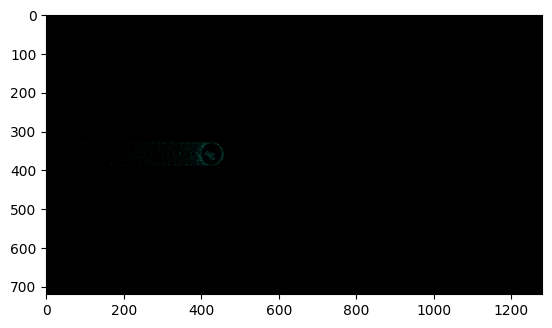

In [21]:
plt.imshow(events_images_rgb[200])

In [25]:
events_roi = []
roi_size = 100
half = roi_size // 2

H, W = events_images_rgb[0].shape[:2]  # RGB images: (H,W,3)

for idx, row in df.iterrows():
    cx = int(row["screen_x"])
    cy = int(row["screen_y"])

    # Top-left corner of ROI
    x1 = cx - half
    y1 = cy - half

    # Clamp so ROI stays fully inside the image
    x1 = max(0, min(W - roi_size, x1))
    y1 = max(0, min(H - roi_size, y1))

    x2 = x1 + roi_size
    y2 = y1 + roi_size

    roi = events_images_rgb[idx][y1:y2, x1:x2].copy()  # (100,100,3)
    events_roi.append(roi)

# Optional: stack into numpy array (N,100,100,3)
events_roi = np.stack(events_roi, axis=0)

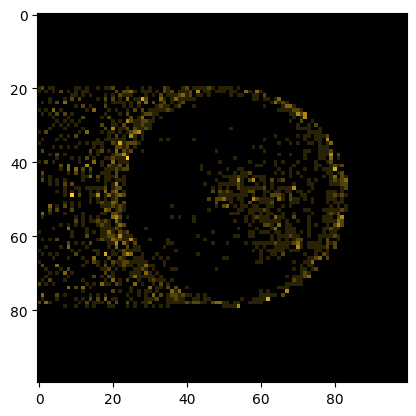

In [27]:
plt.imshow(events_roi[500])

In [28]:
events_images_uint8 = events_images_rgb
events_roi_uint8 = events_roi

In [33]:
from collections import deque

In [43]:
video_path = "/home/levin/dev/Master_Thesis/data/events_images.mp4"   # path to your mp4 file

cap = cv2.VideoCapture(video_path)

frames = []
fps = cap.get(cv2.CAP_PROP_FPS)

while True:
    ret, frame = cap.read()
    if not ret:
        break
    
    #frames.append(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))  # Convert to RGB for consistency
    frames.append(frame)

cap.release()

print(f"Loaded {len(frames)} frames")
print(f"Video FPS: {fps}")

Loaded 601 frames
Video FPS: 30.0


In [44]:
# --- style knobs ---
SPIN_RPS = 66.67
roi_size = 100
half_size = roi_size // 2

# Tracking HUD colors (BGR)
ACCENT = (0, 255, 180)      # teal-ish
ACCENT_DIM = (0, 120, 90)   # dim accent for subtle lines
TEXT = (235, 245, 255)      # near-white
PLATE = (18, 18, 18)        # dark plate

# Keep a short motion trail for "object tracking" vibe
trail = deque(maxlen=18)

def clamp_xyxy(x1, y1, x2, y2, W, H):
    x1 = int(max(0, min(x1, W - 1)))
    y1 = int(max(0, min(y1, H - 1)))
    x2 = int(max(0, min(x2, W)))
    y2 = int(max(0, min(y2, H)))
    # Ensure valid
    if x2 <= x1: x2 = min(W, x1 + 1)
    if y2 <= y1: y2 = min(H, y1 + 1)
    return x1, y1, x2, y2

def draw_corner_box(img, x1, y1, x2, y2, color=ACCENT, thickness=2, corner_len=18):
    # subtle inner rect
    cv2.rectangle(img, (x1, y1), (x2, y2), ACCENT_DIM, 1)

    # corners
    cv2.line(img, (x1, y1), (x1 + corner_len, y1), color, thickness)
    cv2.line(img, (x1, y1), (x1, y1 + corner_len), color, thickness)

    cv2.line(img, (x2, y1), (x2 - corner_len, y1), color, thickness)
    cv2.line(img, (x2, y1), (x2, y1 + corner_len), color, thickness)

    cv2.line(img, (x1, y2), (x1 + corner_len, y2), color, thickness)
    cv2.line(img, (x1, y2), (x1, y2 - corner_len), color, thickness)

    cv2.line(img, (x2, y2), (x2 - corner_len, y2), color, thickness)
    cv2.line(img, (x2, y2), (x2, y2 - corner_len), color, thickness)

def alpha_plate(img, x, y, w, h, color=PLATE, alpha=0.55):
    H, W = img.shape[:2]
    x1 = max(0, min(x, W - 1))
    y1 = max(0, min(y, H - 1))
    x2 = max(0, min(x + w, W))
    y2 = max(0, min(y + h, H))

    overlay = img.copy()
    cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0, img)

def put_hud(img, x1, y1, x2, y2, text_lines, accent=ACCENT):
    """Draw a semi-transparent plate under the bbox with an accent bar."""
    font = cv2.FONT_HERSHEY_SIMPLEX
    scale = 0.55
    thickness = 1
    pad = 8
    gap = 6

    sizes = [cv2.getTextSize(t, font, scale, thickness)[0] for t in text_lines]
    tw = max(s[0] for s in sizes)
    th = sum(s[1] for s in sizes) + gap * (len(text_lines) - 1)

    plate_w = tw + 2 * pad + 10
    plate_h = th + 2 * pad

    # place plate just below bbox, left-aligned with bbox
    px = x1
    py = y2 + 8

    # if too low, flip above bbox
    H, W = img.shape[:2]
    if py + plate_h > H:
        py = max(0, y1 - 8 - plate_h)

    alpha_plate(img, px, py, plate_w, plate_h, color=PLATE, alpha=0.55)

    # accent bar
    cv2.rectangle(img, (px, py), (min(px + 6, W), min(py + plate_h, H)), accent, -1)

    # text
    cy = py + pad
    for t in text_lines:
        (w, h) = cv2.getTextSize(t, font, scale, thickness)[0]
        cv2.putText(img, t, (px + pad + 10, cy + h), font, scale, TEXT, thickness, cv2.LINE_AA)
        cy += h + gap

def glow_box(img, x1, y1, x2, y2, base=ACCENT):
    """Quick glow: draw thicker, darker strokes behind."""
    # glow layer
    for t, c in [(6, (0, 70, 50)), (4, (0, 140, 100))]:
        draw_corner_box(img, x1, y1, x2, y2, color=c, thickness=t, corner_len=20)
    # crisp top layer
    draw_corner_box(img, x1, y1, x2, y2, color=base, thickness=2, corner_len=20)

# ---- main: annotate frames in-place ----
# frames is assumed to be a list of BGR images (numpy arrays)
# df has columns 'screen_x' and 'screen_y' and matches frames indexing

annotated_frames = []

for idx, row in df.iterrows():
    frame = frames[idx].copy()
    H, W = frame.shape[:2]

    x = int(row["screen_x"])
    y = int(row["screen_y"])

    x1 = x - half_size
    y1 = y - half_size
    x2 = x + half_size
    y2 = y + half_size
    x1, y1, x2, y2 = clamp_xyxy(x1, y1, x2, y2, W, H)

    # update trail (center point)
    cx, cy = (x1 + x2) // 2, (y1 + y2) // 2
    trail.append((cx, cy))

    # draw trail (fading)
    for i in range(1, len(trail)):
        p1, p2 = trail[i - 1], trail[i]
        # thickness fades with age
        t = max(1, int(4 * (i / len(trail))))
        cv2.line(frame, p1, p2, ACCENT_DIM, t, cv2.LINE_AA)

    # bbox + glow
    glow_box(frame, x1, y1, x2, y2)

    # little "measurement tick" line
    cv2.line(frame, (x2, y1), (min(W - 1, x2 + 20), y1), ACCENT, 2, cv2.LINE_AA)
    cv2.line(frame, (x2, y1), (x2, max(0, y1 - 20)), ACCENT, 2, cv2.LINE_AA)

    # HUD text under bbox
    hud_lines = [
        "Object: TT Ball",
        f"Spin: Backspin {SPIN_RPS:.2f} rps",
        "State: TRACKED"
    ]
    put_hud(frame, x1, y1, x2, y2, hud_lines)

    annotated_frames.append(frame)

# annotated_frames now contains your "cool & scientific" tracked video frames

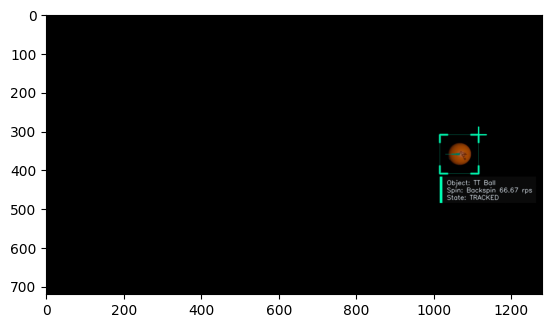

In [38]:
plt.imshow(annotated_frames[500])

In [45]:
# Save to video (uses the same FPS as your source if you know it; otherwise set fps manually)
out_path = "/home/levin/dev/Master_Thesis/data/events_tracked.mp4"
fps = 30  # <- set this to your real FPS
H, W = annotated_frames[0].shape[:2]

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
vw = cv2.VideoWriter(out_path, fourcc, fps, (W, H))

for f in annotated_frames:
    vw.write(f)

vw.release()
print("Saved:", out_path)

Saved: /home/levin/dev/Master_Thesis/data/events_tracked.mp4
